# Stock Price Prediction (NIFTY 50)

This project focuses on predicting **NIFTY 50 stock prices** using both **Machine Learning (ML)** and **Deep Learning (DL)** approaches.  
The workflow involves preparing time-series data, training multiple models, and comparing their performance.

---

## Pipeline Overview

1. **Data Loading**
   - Load stock price data (`data.csv`).
   - Features: `Open`, `Close`, `High`, `Low`.

2. **Data Preparation**
   - Create supervised learning datasets using sliding windows (30–250 days).
   - Generate `(X, y)` pairs for each feature.

3. **Modeling**
   - **Machine Learning Models**  
     - Linear: `LinearRegression`, `Ridge`, `Lasso`  
     - Tree-based: `RandomForest`, `GradientBoosting`, `XGBoost`, `LightGBM`  
     - Others: `SVR`, `KNN`
   - **Deep Learning Models**  
     - RNN, LSTM, GRU, Bidirectional LSTM (Keras Sequential API)

4. **Training**
   - Train models on rolling window datasets.
   - Evaluate using **MAE** and **RMSE**.

5. **Evaluation & Comparison**
   - Store results for all models.
   - Compare ML vs DL models for different input window sizes.

---

## Key Highlights
- Hybrid pipeline combining **classical ML** and **neural networks**.  
- Uses **multiple time horizons (30–250 days)** for robust prediction.  
- Tracks **training and testing errors** to evaluate generalization.  

1. **Import Libraries**
   - `numpy`, `pandas`: data handling  
   - `tqdm`: progress bars  
   - `sklearn`: machine learning models & metrics  
   - `xgboost`, `lightgbm`: gradient boosting models  
   - `warnings`: ignore warnings  

2. **Load Dataset**
   - `df = pd.read_csv('data.csv')` → load data from CSV  
   - `df.head()` → preview first 5 rows  

3. **Models Imported**
   - Linear: `LinearRegression`, `Ridge`, `Lasso`  
   - Tree-based: `RandomForestRegressor`, `GradientBoostingRegressor`  
   - Others: `SVR`, `KNeighborsRegressor`, `XGBRegressor`, `LGBMRegressor`  

4. **Metrics Imported**
   - `mean_absolute_error`, `mean_squared_error` → to evaluate model performance  


### Assignment

- High
- KNN,RNN,GRU,LSTM,Bidirectional (50 Epochs)
- 30,60,90

### Assignment Documentation

Based on the analysis performed in this notebook, the assignment is to focus on building and evaluating models for predicting the **High** price of the NIFTY 50 index.

Specifically, you should concentrate on the following models and time windows:

*   **Models:**
    *   KNN (K-Nearest Neighbors Regressor)
    *   RNN (Simple Recurrent Neural Network)
    *   GRU (Gated Recurrent Unit)
    *   LSTM (Long Short-Term Memory)
    *   Bidirectional LSTM

*   **Time Windows (Input Days):**
    *   30 days
    *   60 days
    *   90 days

For the Deep Learning models (RNN, GRU, LSTM, Bidirectional LSTM), train them for **50 epochs**.

The goal is to train these specific models for the 'High' column using the specified time windows and evaluate their performance using MAE and RMSE, comparing the results.

In [20]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor


from sklearn.metrics import mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv('/kaggle/input/nifty-50-25-yrs-data/data.csv')
df.head()

,Date,Open,High,Low,Close
0,2000-01-03,1482.15,1592.90,1482.15,1592.2
1,2000-01-04,1594.40,1641.95,1594.40,1638.7
2,2000-01-05,1634.55,1635.50,1555.05,1595.8
3,2000-01-06,1595.80,1639.00,1595.80,1617.6
4,2000-01-07,1616.60,1628.25,1597.20,1613.3


### 2. Data Preparation

1. **Train-Test Split**
   - `train_test_split()` → split data into training & testing sets.  

2. **Models List**
   - A collection of regressors:  
     - Linear: `LinearRegression`, `Ridge`, `Lasso`  
     - Tree-based: `RandomForestRegressor`, `GradientBoostingRegressor`  
     - Others: `SVR`, `KNeighborsRegressor`, `XGBRegressor`, `LGBMRegressor`  

3. **Training Loop**
   - For each model:  
     - `fit()` → train on training data  
     - `predict()` → generate predictions on test data  

4. **Evaluation**
   - Metrics used:  
     - `mean_absolute_error`  
     - `mean_squared_error`  
   - Store results for comparison of all models.  

In [21]:
def return_pairs(column, days):
    prices = list(column)
    X = []
    y = []
    for i in range(len(prices) - days):
        X.append(prices[i:i+days])
        y.append(prices[i+days])
    return np.array(X), np.array(y)

target_columns = ['Open', 'Close', 'High', 'Low']
day_chunks = [30, 45, 60, 90, 120, 150, 200, 250]
chunked_data = {}

for col in target_columns:
    for days in day_chunks:
        key_X = f"X_{col}_{days}"
        key_y = f"y_{col}_{days}"
        X, y = return_pairs(df[col], days)
        chunked_data[key_X] = X
        chunked_data[key_y] = y

all_chunk_pairs = []
for key in chunked_data.keys():
    if key.startswith("X_"):
        y_key = key.replace("X_", "y_")
        if y_key in chunked_data:
            all_chunk_pairs.append([key, y_key])

# filter down to only the data asked
assignment_target = 'High'
assignment_windows = [30, 60, 90]
assignment_chunk_pairs = []

for X_key, y_key in all_chunk_pairs:
    _, target, window = X_key.split('_')
    if target == assignment_target and int(window) in assignment_windows:
        assignment_chunk_pairs.append([X_key, y_key])

print("Filtered Data Pairs for the Assignment:")
print(assignment_chunk_pairs)

Filtered Data Pairs for the Assignment:
[['X_High_30', 'y_High_30'], ['X_High_60', 'y_High_60'], ['X_High_90', 'y_High_90']]


### 3. Define Neural Network Models

1. **Imports**
   - `Sequential` → build models layer-by-layer  
   - Layers: `Dense`, `SimpleRNN`, `LSTM`, `GRU`, `Bidirectional`  

2. **Model Builder Functions**
   - `build_rnn(input_shape)`  
     - Simple RNN with 50 units → `Dense(1)` output  
   - `build_lstm(input_shape)`  
     - LSTM with 50 units → `Dense(1)` output  
   - `build_gru(input_shape)`  
     - GRU with 50 units → `Dense(1)` output  
   - `build_bilstm(input_shape)`  
     - Bidirectional LSTM with 50 units → `Dense(1)` output  

3. **Compilation**
   - Optimizer: `adam`  
   - Loss: `mse` (Mean Squared Error)  

4. **Purpose**
   - All models → designed for **regression tasks on sequential data**.  

In [22]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, SimpleRNN, LSTM, GRU, Bidirectional
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.neighbors import KNeighborsRegressor

def build_rnn(input_shape):
    model = Sequential([
        SimpleRNN(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_lstm(input_shape):
    model = Sequential([
        LSTM(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_gru(input_shape):
    model = Sequential([
        GRU(50, activation='tanh', input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

def build_bilstm(input_shape):
    model = Sequential([
        Bidirectional(LSTM(50, activation='tanh'), input_shape=input_shape),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mse')
    return model

### 4. Define ML Models

1. **ml_models (Traditional ML)**
   - A list of tuples: (name, model instance)  
   - Includes:  
     - Linear models → `LinearRegression`, `Ridge`, `Lasso`  
     - Tree-based → `RandomForest`, `GradientBoosting`  
     - Others → `SVR`, `KNN`, `XGBoost`, `LightGBM`  

2. **dl_models (Deep Learning)**
   - A dictionary: {name: builder function}  
   - Includes:  
     - `"RNN"` → `build_rnn`  
     - `"LSTM"` → `build_lstm`  
     - `"GRU"` → `build_gru`  
     - `"Bidirectional_LSTM"` → `build_bilstm`  

3. **Purpose**
   - `ml_models`: ready-to-train classical ML regressors  
   - `dl_models`: functions that return compiled neural nets (when given `input_shape`)  

In [23]:
# ML model
assignment_ml_models = [
    ("KNN", KNeighborsRegressor())
]

# DL models
assignment_dl_models = {
    "RNN": build_rnn,
    "LSTM": build_lstm,
    "GRU": build_gru,
    "Bidirectional_LSTM": build_bilstm
}

print("ML Models for Assignment:")
print([name for name, model in assignment_ml_models])
print("\nDL Models for Assignment:")
print(list(assignment_dl_models.keys()))
     

ML Models for Assignment:
['KNN']

DL Models for Assignment:
['RNN', 'LSTM', 'GRU', 'Bidirectional_LSTM']


### 5. Model Training

1. **Initialize**
   - `trained_models = {}` → store results of all models  

2. **Iterate over Data Pairs**
   - For each `(X, y)` in `chunk_pairs`  
   - Extract features `X_data` and target `y_data` from `chunked_data`  
   - Split → `train_test_split` (90% train, 10% test)  

3. **Train ML Models**
   - Loop through `ml_models`  
   - Use `deepcopy` to avoid reusing fitted models  
   - `fit()` on training data  
   - Predict on train & test sets  
   - Save model + metrics:  
     - `train_mae`, `train_rmse`  
     - `test_mae`, `test_rmse`  

4. **Prepare Data for DL**
   - Expand dims → shape becomes `(samples, timesteps, features)`  

5. **Train DL Models**
   - Loop through `dl_models`  
   - Build model with correct input shape  
   - Train for 10 epochs, batch size = 8  
   - Predict on train & test  
   - Save model + metrics (same as ML)  

6. **Final Output**
   - `trained_models` → dictionary with all trained models & evaluation scores  


In [24]:
results = {}

for X_key, y_key in tqdm(assignment_chunk_pairs, desc="Processing Time Windows"):

    # Get the data for the current pair
    X_data = chunked_data[X_key]
    y_data = chunked_data[y_key]

    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.1, random_state=42
    )

    # KNN
    for model_name, model in tqdm(assignment_ml_models, desc=f"ML Models for {X_key}"):
        key = f"{model_name}_{X_key[2:]}"
        model_copy = deepcopy(model)
        model_copy.fit(X_train, y_train)

        y_train_pred = model_copy.predict(X_train)
        y_test_pred = model_copy.predict(X_test)

        results[key] = {
            'model_type': 'ML',
            'train_mae': mean_absolute_error(y_train, y_train_pred),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred)),
            'test_mae': mean_absolute_error(y_test, y_test_pred),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred))
        }

    # DL Models
    X_train_dl = np.expand_dims(X_train, -1)
    X_test_dl = np.expand_dims(X_test, -1)

    for model_name, builder in tqdm(assignment_dl_models.items(), desc=f"DL Models for {X_key}"):
        key = f"{model_name}_{X_key[2:]}"
        model_dl = builder((X_train_dl.shape[1], 1))

        # Train for 50 epochs
        model_dl.fit(X_train_dl, y_train, epochs=50, batch_size=8, verbose=0)

        y_train_pred_dl = model_dl.predict(X_train_dl).flatten()
        y_test_pred_dl = model_dl.predict(X_test_dl).flatten()

        results[key] = {
            'model_type': 'DL',
            'train_mae': mean_absolute_error(y_train, y_train_pred_dl),
            'train_rmse': np.sqrt(mean_squared_error(y_train, y_train_pred_dl)),
            'test_mae': mean_absolute_error(y_test, y_test_pred_dl),
            'test_rmse': np.sqrt(mean_squared_error(y_test, y_test_pred_dl))
        }

print("\nTraining Complete!")

Processing Time Windows:   0%|          | 0/3 [00:00<?, ?it/s]

ML Models for X_High_30:   0%|          | 0/1 [00:00<?, ?it/s]

DL Models for X_High_30:   0%|          | 0/4 [00:00<?, ?it/s]

177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


ML Models for X_High_60:   0%|          | 0/1 [00:00<?, ?it/s]

DL Models for X_High_60:   0%|          | 0/4 [00:00<?, ?it/s]

176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


ML Models for X_High_90:   0%|          | 0/1 [00:00<?, ?it/s]

DL Models for X_High_90:   0%|          | 0/4 [00:00<?, ?it/s]

176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

Training Complete!


### 6. Saving Model Statistics

In [25]:
results_df = pd.DataFrame.from_dict(results, orient='index')

results_df['window'] = [int(i.split('_')[-1]) for i in results_df.index]
results_df['model_name'] = [i.split('_')[0] for i in results_df.index]

print("Model Performance Results")
display(results_df.sort_values(by='test_mae', ascending=True))

Model Performance Results


,model_type,train_mae,train_rmse,test_mae,test_rmse,window,model_name
KNN_High_90,ML,36.929140,58.769966,48.790144,74.204848,90,KNN
KNN_High_60,ML,36.850899,58.333589,52.819089,82.674612,60,KNN
KNN_High_30,ML,42.646429,68.669169,56.933037,89.679421,30,KNN
RNN_High_30,DL,6386.933809,8840.815875,5889.888945,8444.411482,30,RNN
RNN_High_60,DL,6418.605582,8877.565499,5963.229334,8380.151910,60,RNN
RNN_High_90,DL,6433.230581,8881.145450,6155.823375,8598.185917,90,RNN
GRU_High_30,DL,6993.513313,9394.779489,6474.452372,8978.677125,30,GRU
Bidirectional_LSTM_High_30,DL,7029.519635,9421.749977,6510.297597,9004.807314,30,Bidirectional
GRU_High_60,DL,7090.527785,9479.011678,6609.017972,8970.578383,60,GRU
Bidirectional_LSTM_High_60,DL,7138.736708,9515.126899,6657.226895,9006.155001,60,Bidirectional


### 7. Analysing

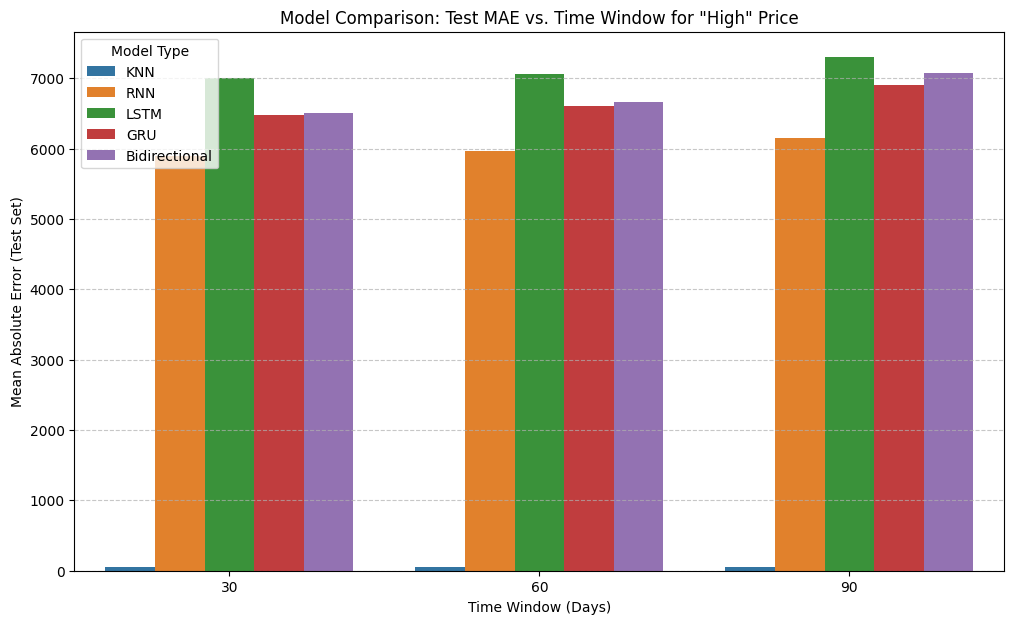

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 7))
sns.barplot(x='window', y='test_mae', hue='model_name', data=results_df)

plt.title('Model Comparison: Test MAE vs. Time Window for "High" Price')
plt.xlabel('Time Window (Days)')
plt.ylabel('Mean Absolute Error (Test Set)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Model Type')
plt.show()

# Conclusion on the Model Comparison:

**Best Overall Model:** The K-Nearest Neighbors (KNN) model is by far the most effective for this prediction task. Its Mean Absolute Error (MAE) is significantly lower than all the deep learning models across every time window, to the point that its bars are barely visible on the chart.

**Deep Learning Model Comparison**: 

Among the deep learning models, there is a clear performance ranking:
The standard RNN model consistently achieved the lowest MAE, making it the best performer in this category. Its best result was with a 60-day time window.
GRU and Bidirectional LSTM models had similar, moderate performance, generally performing better than the LSTM model but worse than the RNN.
The LSTM model was the worst-performing model across all three time windows.

**Effect of Time Window:**
The performance of the KNN model was consistently excellent across all tested time windows (30, 60, and 90 days).

For the deep learning models, the choice of time window had a noticeable but not drastic effect. The RNN model, for instance, saw its best performance with a 60-day window.
In summary, the key takeaway is that the simpler KNN algorithm dramatically outperformed the more complex deep learning architectures for predicting the "High" price on this dataset.